In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Network Overhead

In [2]:
def n_vs_amplify(ax, ns, c, label):
    d_t = 1.5
    shard_size = 10
    sigma = 0.1
    ys = 1 + np.clip(ns - c, min=0) / ns * d_t * shard_size * sigma
    # print(ys)
    ax.plot(ns, ys, label=label)

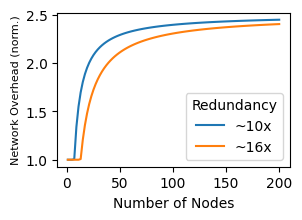

In [ ]:
fig, ax = plt.subplots(figsize=(3, 2))
n_vs_amplify(ax, np.linspace(1, 200, 100), 7, "~10x")
n_vs_amplify(ax, np.linspace(1, 200, 100), 13, "~16x")
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Network Overhead (norm.)", fontsize=8)
ax.legend(title="Redundancy")

In [4]:
fig.savefig("network-overhead.pdf", bbox_inches="tight")

# Blockchain State Size

In [39]:
import polars as pl
eth_state_size = pl.read_csv("export-ClientDataSyncDefault.csv")
eth_state_size = eth_state_size.with_columns(
    pl.col("Date(UTC)").str.to_date("%m/%d/%Y").alias("Date"),
    (pl.col("Value") / 1_000_000_000).alias("Size (GB)"))
eth_state_size

Date(UTC),BlockNumber,UnixTimeStamp,Value,ClientVersion,Date,Size (GB)
str,i64,i64,i64,str,date,f64
"""1/23/2019""",7111289,1548202180,180427595683,"""1.8.21""",2019-01-23,180.427596
"""1/24/2019""",7116274,1548288519,180427599016,"""1.8.21""",2019-01-24,180.427599
"""1/25/2019""",7121375,1548374948,181437999437,"""1.8.21""",2019-01-25,181.437999
"""1/26/2019""",7126462,1548461373,181438824915,"""1.8.21""",2019-01-26,181.438825
"""1/27/2019""",7131517,1548547768,181439384907,"""1.8.21""",2019-01-27,181.439385
…,…,…,…,…,…,…
"""5/20/2025""",22520476,1747699799,1409056424475,"""1.15.10""",2025-05-20,1409.056424
"""5/21/2025""",22527606,1747786199,1410030989151,"""1.15.10""",2025-05-21,1410.030989
"""5/22/2025""",22534747,1747872599,1411136003725,"""1.15.10""",2025-05-22,1411.136004


In [28]:
import json
with open("blocks-size.json") as f:
    btc_state_size = json.load(f)["blocks-size"]
btc_state_size = pl.DataFrame(btc_state_size)
btc_state_size = btc_state_size.with_columns(
    pl.from_epoch("x", time_unit="ms").alias("Date"),
    (pl.col("y") / 1_000).alias("Size (GB)"),
)
btc_state_size

x,y,Date,Size (GB)
i64,f64,datetime[ms],f64
1230940800000,0.000285,2009-01-03 00:00:00,2.8500e-7
1231718400000,0.036672,2009-01-12 00:00:00,0.000037
1232064000000,0.143568,2009-01-16 00:00:00,0.000144
1232409600000,0.241267,2009-01-20 00:00:00,0.000241
1232755200000,0.329295,2009-01-24 00:00:00,0.000329
…,…,…,…
1746316800000,656410.324863,2025-05-04 00:00:00,656.410325
1746662400000,657404.715569,2025-05-08 00:00:00,657.404716
1747008000000,658401.952726,2025-05-12 00:00:00,658.401953


In [ ]:
eth_state_size["Date"].min()

datetime.date(2019, 1, 23)

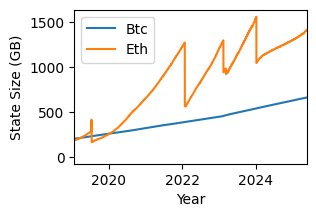

In [38]:
import matplotlib.dates

fig, ax = plt.subplots(figsize=(3, 2))

ax.plot(btc_state_size["Date"], btc_state_size["Size (GB)"], label="Btc")
ax.plot(eth_state_size["Date"], eth_state_size["Size (GB)"], label="Eth")

ax.set_xlabel("Year")
ax.set_xlim(eth_state_size["Date"].min(), eth_state_size["Date"].max())
ax.xaxis.set_major_locator(matplotlib.dates.YearLocator(2))
ax.set_ylabel("State Size (GB)")
ax.legend()

In [40]:
fig.savefig("states-grow.pdf", bbox_inches="tight")